# Beyond Counting Individual Words: N-grams


So far in our journey through text data processing, we've dealt with counting individual words. While this approach, often referred to as a "bag of words" model, can provide a basic level of understanding and can be useful for certain tasks, it often falls short in capturing the true complexity and richness of language. This is mainly because it treats each word independently and ignores the context and order of words, which are fundamental to human language comprehension.

For example, consider the two phrases  
*"The movie is good, but the actor was bad."*  
and  
*"The movie is bad, but the actor was good."*  

If we simply count individual words, both phrases are identical because they contain the exact same words!
However, their meanings are diametrically opposed. The order of words and the context in which they are used are important.

## N-grams

**N-grams** are continuous sequences of n items in a given sample of text or speech. In the context of text analysis, an item can be a character, a syllable, or a word, although words are the most commonly used items. The integer *n* in "n-gram" refers to the number of items in the sequence, so a bigram (or 2-gram) is a sequence of two words, a trigram (3-gram) is a sequence of three words, and so on.

To illustrate, consider the two sentences above.
With 3-grams we could also get the pieces "movie is good", "movie is bad", "actor was bad", and "actor was good".
Bigrams (or 2-grams) would not catch those differences. However, they can be helpful in slightly simpler cases, such as "don't like" versus "do like" (see {numref}`fig_ngrams_example`). A lot will depend here on the text normalization and tokenization process. In some cases `don't` will be interpreted as two tokens (`do` and `not`), while other workflows might leave it at `don't` or `don'` (for instance the `TfidfVectorizer` from Sckit-Learn). In the first case, we would again need 3-grams to fully represent the "don't" like as `("do", "not", "like")`.

```{figure} ../images/fig_ngrams_example.png
:name: fig_ngrams_example

Two example sentences can be compared based on the words they contain (left table). But in many cases, meaningful distinctions get more pronounced when including n-grams (here: 2-grams added ot the right table). Identical words and 2-grams between the sentences are marked by yellow boxes.
```

Now we will see how we can make use of such n-grams.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.feature_extraction.text import TfidfVectorizer


# Set the ggplot style
plt.style.use("ggplot")

## N-grams in TF-IDF Vectors

When creating TF-IDF vectors, we can incorporate the concept of n-grams. The scikit-learn `TfidfVectorizer` provides the `ngram_range` parameter that allows us to specify the range of n-grams to include in the feature vectors. Setting this parameter to `(1, 3)` for instance, meant that 1-grams, 2-grams, and 3-grams will be included. So better be careful to not add too high numbers for ngram_range. Why? Well, let's see. But we will start by importing a dataset with plenty of text documents in it.

### Dataset - Madrid Restaurant Reviews
We will now use a large, text-based dataset containing more than 176.000 restaurant reviews from Madrid ([see dataset on zenodo](https://zenodo.org/records/6583422)). The dataset (about 142MB) can be downloaded via the given link.

In the following, however, we will work with "only" the first 40,000 entries of this dataset, and the following code block will download that subset from the data sharing platform **Zenodo**. If you want to experiment on your own, simply go to the original dataset (see link above) and try to re-run the following code pieces with the full dataset. One question worth asking would then be: Does this improve the models?

In [59]:
"""
This code block downloads the data from zenodo and stores it in a local 'datasets' folder.
"""

import requests
import os


def download_from_zenodo(url, save_path):
    """
    Downloads a file from a given Zenodo link and saves it to the specified path.

    Parameters:
    - url: The Zenodo link to the file to be downloaded.
    - save_path: Path where the file should be saved.
    """

    # Check if the file already exists
    if os.path.exists(save_path):
        print(f"File {save_path} already exists. Skipping download.")
        return None

    response = requests.get(url, stream=True)
    response.raise_for_status()

    with open(save_path, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)

    print(f"File downloaded successfully and saved to {save_path}")


# Zenodo link to the dataset
zenodo_link = r"https://zenodo.org/records/21107801/files/reviews_madrid_40k.csv?download=1"

# Path to save the downloaded dataset (you can modify this as needed)
output_path = os.path.join("..", "datasets", "reviews_madrid_40k.csv")

# Create directory if it doesn't exist
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# Download the dataset
download_from_zenodo(zenodo_link, output_path)

File downloaded successfully and saved to ..\datasets\reviews_madrid_40k.csv


In [60]:
filename = "../datasets/reviews_madrid_40k.csv"
data = pd.read_csv(filename)
data.head()

,rating_review,title_review,review_full,date,city
0,2,Friendly fakey,'Vegetable Korma' was really just a bland yell...,"March 12, 2013",Madrid
1,5,Great value & home made.,A typical restaurant/bar very popular with loc...,"February 15, 2018",Madrid
2,3,Great salmon! Big serving.,Though the place looks a bit old and some of t...,"September 27, 2013",Madrid
3,2,Apauling management,My boyfriend and I came here for a birthday lu...,"September 10, 2015",Madrid
4,2,"Poor Service, paella was not prepared properly...",It is almost impossible to get a bad meal in M...,"October 6, 2015",Madrid


In [61]:
data.shape

(40000, 5)

As we can see, we have a pretty extensive dataset with many different restaurant reviews, our documents (`review_full`), as well as ratings (`rating_review`). We will use both of them in the following part. Let's first check a few random examples of our reviews, just to get a first idea of how the data looks like.

In [4]:
data.review_full.iloc[0]

"'Vegetable Korma' was really just a bland yellow curry?frozen peas & carrots, turmeric, milk, maybe a bit of onion. Papadums OK. Others said other dishes were fine. But all lacked the odors of the many spices I've come to expect from India."

## TF-IDF with Bigrams: Growing Vectors and Managing High Dimensionality

As we did in the previous chapters, we can simply use the Scikit-Learn `TfidfVectorizer` to create tfidf-vectors of our documents. But now with `ngram_range` set to more than just 1-grams. For a start, we will use 1-grams and 2-grams:

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

# considers both unigrams and bigrams
vectorizer = TfidfVectorizer(ngram_range=(1, 2))  

tfidf_vectors = vectorizer.fit_transform(data.review_full)
tfidf_vectors.shape

(40000, 532156)

Look at the size of those vectors!

Even for 1-grams, the tfidf-vectors we saw in the previous chapters were rather large. But with higher n-grams, this can really explode because there are so much more possible combinations of words. 

So, clearly, using higher n-grams comes at a cost. The more we increase the size of our n-grams, the higher the dimensionality of our feature vectors. In the case of bigrams, for every pair of words that occur together in our text corpus, we add a new dimension to our feature space. This can quickly lead to an explosion of features. For instance, a modest vocabulary of 1,000 words leads to a potential of up to 1,000,000 (1,000 x 1,000) bigrams.

This high dimensionality can lead to two issues:

1. **Sparsity:** Most documents in the corpus will not contain most of the possible bigrams, leading to a feature matrix where most values are zero, i.e., a sparse matrix.
2. **Computational resources:** The computational requirement for storing and processing these feature vectors can become significant, especially for large text corpora.

Several techniques can help manage this high-dimensionality problem:

- **Feature selection:** We can limit the number of bigrams we include in our feature vector. This could be done based on the frequency of the bigrams. For example, we could choose to include only those bigrams that occur more than a certain number of times in the corpus.
- **Dimensionality reduction:** Techniques such as Principal Component Analysis (PCA) or Truncated Singular Value Decomposition (TruncatedSVD) can be used to reduce the dimensionality of the feature space, while preserving as much of the variance in the data as possible.
- **Using Hashing Vectorizer:** Scikit-learn provides a `HashingVectorizer` that uses a hash function to map the features to indices in the feature vector. This approach has a constant memory footprint and does not require to keep a vocabulary dictionary in memory, which makes it suitable for large text corpora.

It's important to weigh the trade-offs between capturing more context using n-grams and managing the resulting high dimensionality.

Let us here use the simplest way to reduce the tfidf vector size: a more restrictive feature selection!

### Restrict the Tfidf Vector Sizes
A very effective parameter for reducing the number of considered n-grams is `min_df`, the minimum document frequency.  
We could increase this to 10, so only n-grams that occur in at least 10 of our documents will be considered for our vectors.

In [5]:
vectorizer = TfidfVectorizer(
    min_df=10,
    max_df=0.2,
    ngram_range=(1, 2)
)  
tfidf_vectors = vectorizer.fit_transform(data.review_full)
tfidf_vectors.shape

(40000, 36817)

This looks much better! Maybe we can even include 3-grams?

In [6]:
vectorizer = TfidfVectorizer(
    min_df=5,
    max_df=0.2,
    ngram_range=(1, 3)
)  
tfidf_vectors = vectorizer.fit_transform(data.review_full)
tfidf_vectors.shape

(40000, 124025)

This looks OK, at least size-wise. The reason why this doesn't explode in terms of vector size is that the `min_df` parameter also counts for 2-grams, 3-grams etc. This here means that only the 3-grams which occur at least `min_df`-times will be kept.

Now we should check which ngrams the tfidf model finally included.

In [7]:
vectorizer.get_feature_names_out()[-100:]

array(['your table to', 'your tapa', 'your tapas', 'your tapas and',
       'your tapas crawl', 'your taste', 'your taste buds',
       'your tastebuds', 'your thing', 'your time', 'your time and',
       'your time here', 'your time in', 'your time or',
       'your time there', 'your time to', 'your to', 'your to do',
       'your tour', 'your trip', 'your trip to', 'your tummy',
       'your turn', 'your typical', 'your typical tapas', 'your usual',
       'your valuables', 'your visit', 'your visit to', 'your visiting',
       'your visiting madrid', 'your waiter', 'your wallet', 'your way',
       'your way around', 'your way in', 'your way through',
       'your way to', 'your wife', 'your wine', 'your wine and', 'youre',
       'yours', 'yourself', 'yourself and', 'yourself at',
       'yourself favor', 'yourself favor and', 'yourself favour',
       'yourself favour and', 'yourself for', 'yourself in',
       'yourself in madrid', 'yourself in the', 'yourself on',
       'yours

Well, that does not always immediately look like very good word combinations. And there are foreign language pieces still in our n-grams.
We do see a lot of 2-grams and 3-grams. Most combinations of 2 or 3 words, however, seem to be grammatically wrong.

Why is that?

The reason is that our selection criteria (using `min_df` and `max_df`) removed a lot of very common words so that **yes it does** becomes **yes does**.
But we can leave it to the machine learning algorithms now to make more sense of it.

First, however, it might be good the reduce the vectors a bit further.
Instead of manually adjusting the `min_df` many times, we can also use the parameter `max_features` to set an upper limit. This will remove all n-grams on the lower document frequency size until the set limit is reached.

In [8]:
vectorizer = TfidfVectorizer(
    min_df=5,
    max_df=0.2,
    ngram_range=(1, 3),
    max_features=10_000,
)  
tfidf_vectors = vectorizer.fit_transform(data.review_full)
tfidf_vectors.shape

(40000, 10000)

In [9]:
vectorizer.get_feature_names_out()[-100:]

array(['you can', 'you can also', 'you can buy', 'you can choose',
       'you can eat', 'you can enjoy', 'you can find', 'you can get',
       'you can go', 'you can have', 'you can order', 'you can see',
       'you can sit', 'you can try', 'you cannot', 'you choose',
       'you come', 'you could', 'you do', 'you do not', 'you don',
       'you don want', 'you eat', 'you enjoy', 'you enter', 'you expect',
       'you feel', 'you feel like', 'you find', 'you for', 'you get',
       'you get to', 'you go', 'you go to', 'you had', 'you have',
       'you have the', 'you have to', 'you in', 'you just', 'you know',
       'you like', 'you like to', 'you ll', 'you ll be', 'you ll find',
       'you love', 'you make', 'you may', 'you might', 'you must',
       'you must visit', 'you need', 'you need to', 'you order',
       'you pay', 'you pay for', 'you re', 'you re in', 'you re looking',
       'you re not', 'you really', 'you see', 'you should', 'you sit',
       'you that', 'you the', 

OK, this looks quite good. Let's try to work with those settings.

First, we do a data split to later train a machine learning model:

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data.review_full, data.rating_review, test_size=0.2, random_state=0)

print(f"Train dataset size: {X_train.shape}")
print(f"Test dataset size: {X_test.shape}")    

Train dataset size: (32000,)
Test dataset size: (8000,)


This time we will start right away with a classification model:

### Logistic Regression model
To later compare models, we will start without n-grams!

And, **important**: We have to set the tfidf-vectorizer on **only** the training data!

In [11]:
vectorizer = TfidfVectorizer(
    min_df=10, max_df=0.2,
    max_features=10000,
    #ngram_range=(1, 3)
)  
tfidf_vectors = vectorizer.fit_transform(X_train)
tfidf_vectors.shape

(32000, 5919)

In [12]:
vectorizer.get_feature_names_out()[-100:]

array(['widely', 'wider', 'wife', 'wifi', 'wild', 'will', 'willing',
       'win', 'wind', 'window', 'windows', 'wine', 'wines', 'wings',
       'winner', 'winning', 'winter', 'wiped', 'wise', 'wisely', 'wish',
       'wished', 'wishes', 'within', 'without', 'witnessed', 'wok',
       'woman', 'women', 'won', 'wonder', 'wondered', 'wonderful',
       'wonderfull', 'wonderfully', 'wondering', 'wont', 'wood', 'wooden',
       'word', 'words', 'wore', 'work', 'worked', 'workers', 'working',
       'works', 'world', 'worlds', 'worn', 'worried', 'worries', 'worry',
       'worse', 'worst', 'worth', 'worths', 'worthwhile', 'worthy',
       'would', 'wouldn', 'wouldnt', 'wow', 'wrap', 'wrapped', 'wraps',
       'write', 'writers', 'writing', 'written', 'wrong', 'wrote', 'xo',
       'xx', 'yamil', 'yeah', 'year', 'years', 'yelled', 'yelling',
       'yellow', 'yes', 'yesterday', 'yet', 'yo', 'yoghurt', 'yogurt',
       'york', 'young', 'younger', 'your', 'youre', 'yourself',
       'yourselve

By the way: Why did we now get less than max_features?

In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=300)  # don't worry it also works without setting max_iter
model.fit(tfidf_vectors, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

We will then use the before initialized tfidf-vectorizer to process our test data.

In [14]:
tfidf_vectors_test = vectorizer.transform(X_test)
predictions = model.predict(tfidf_vectors_test)

In [15]:
np.round(predictions[:20], 1)

array([5, 3, 4, 1, 5, 5, 1, 5, 4, 5, 4, 5, 5, 4, 5, 4, 5, 1, 5, 5])

In [16]:
y_test[:20].values

array([4, 3, 3, 1, 4, 4, 1, 4, 4, 5, 5, 4, 5, 5, 5, 3, 1, 1, 4, 5])

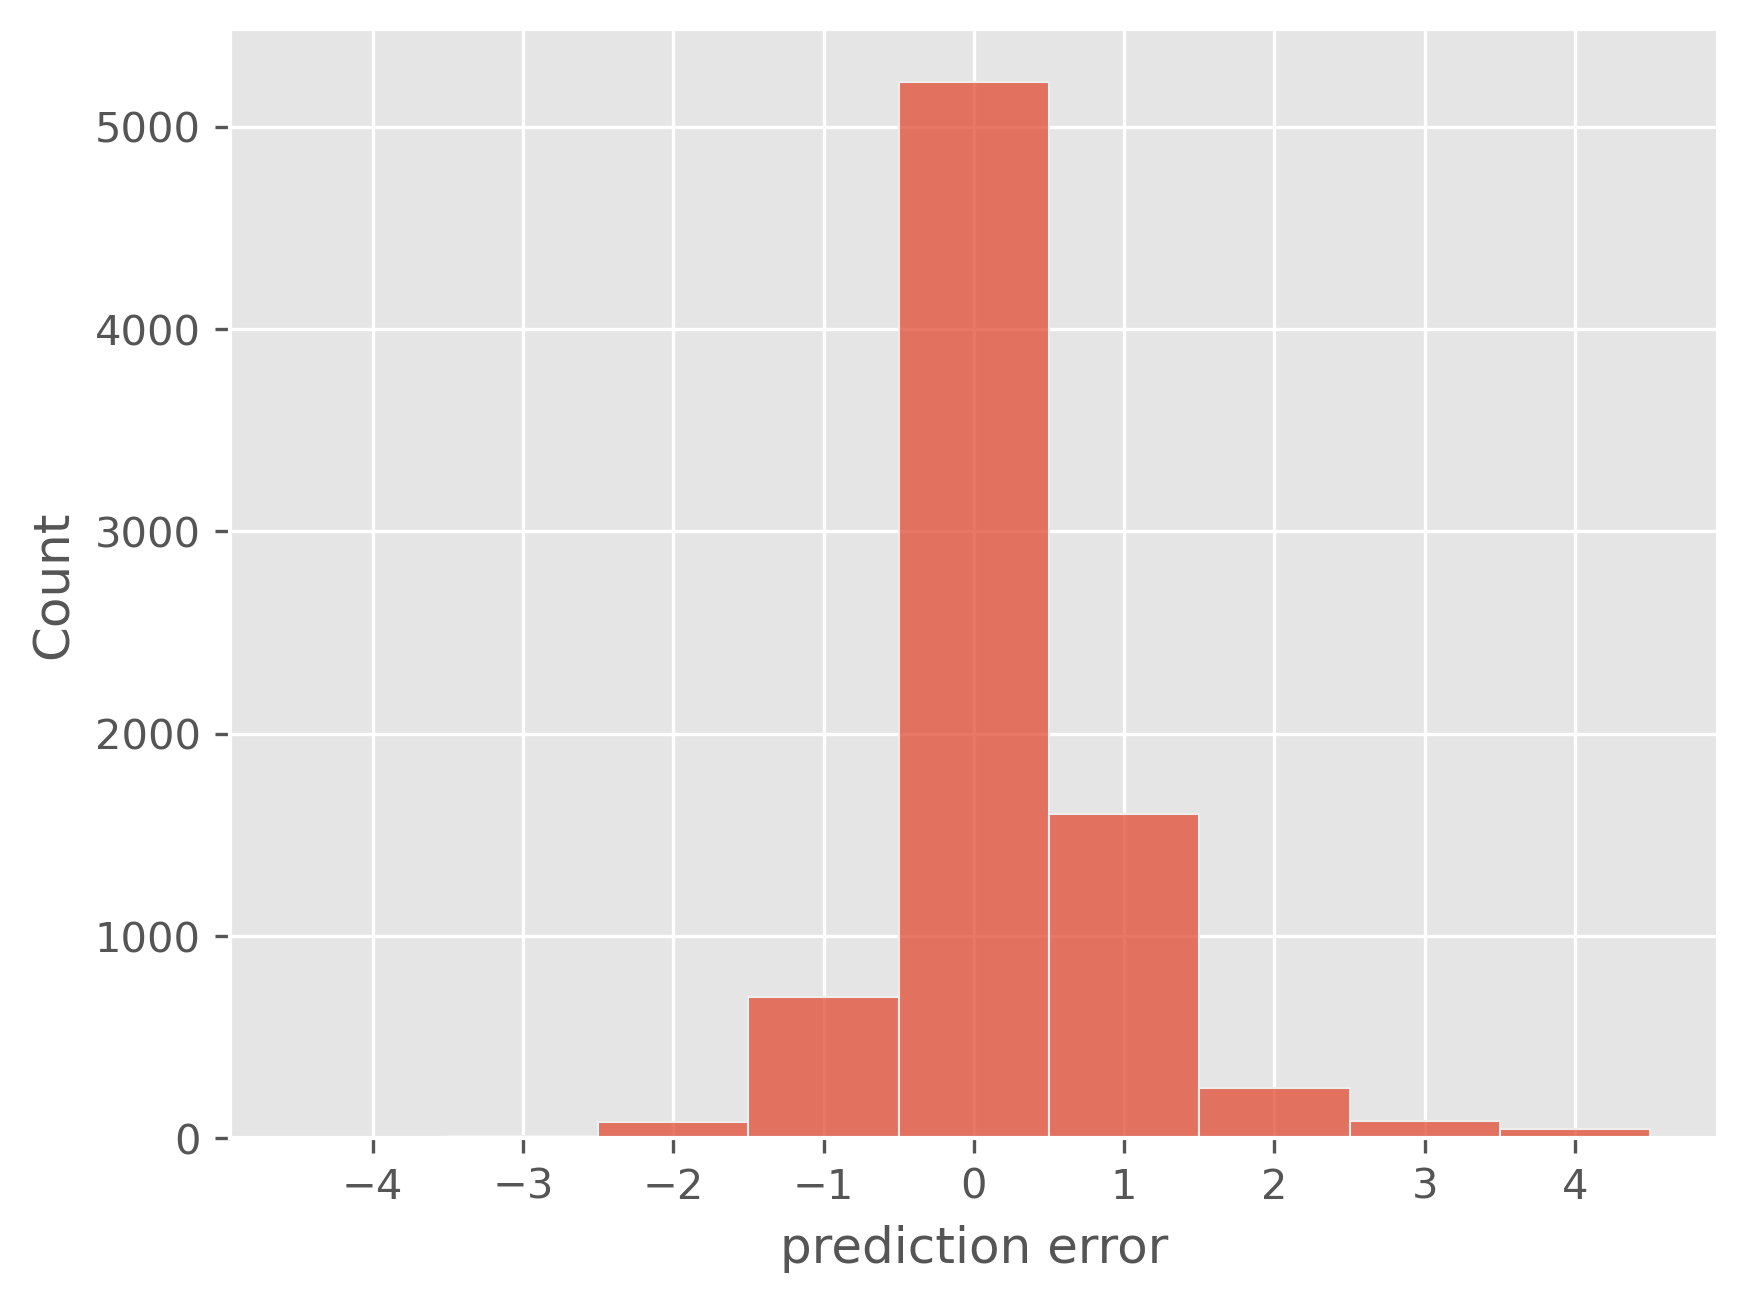

In [17]:
bins = np.arange(-4.5, 5.5, 1)

plt.figure(dpi=300)
sb.histplot(predictions - y_test, bins=bins)
plt.xlabel("prediction error")
plt.xticks(range(-4, 5))  # Set x-ticks to be all integers between -4 and 4
plt.show()

In [18]:
print(f"Mean absolute error (MAE): {np.abs(predictions - y_test).mean():.4f}")

Mean absolute error (MAE): 0.4320


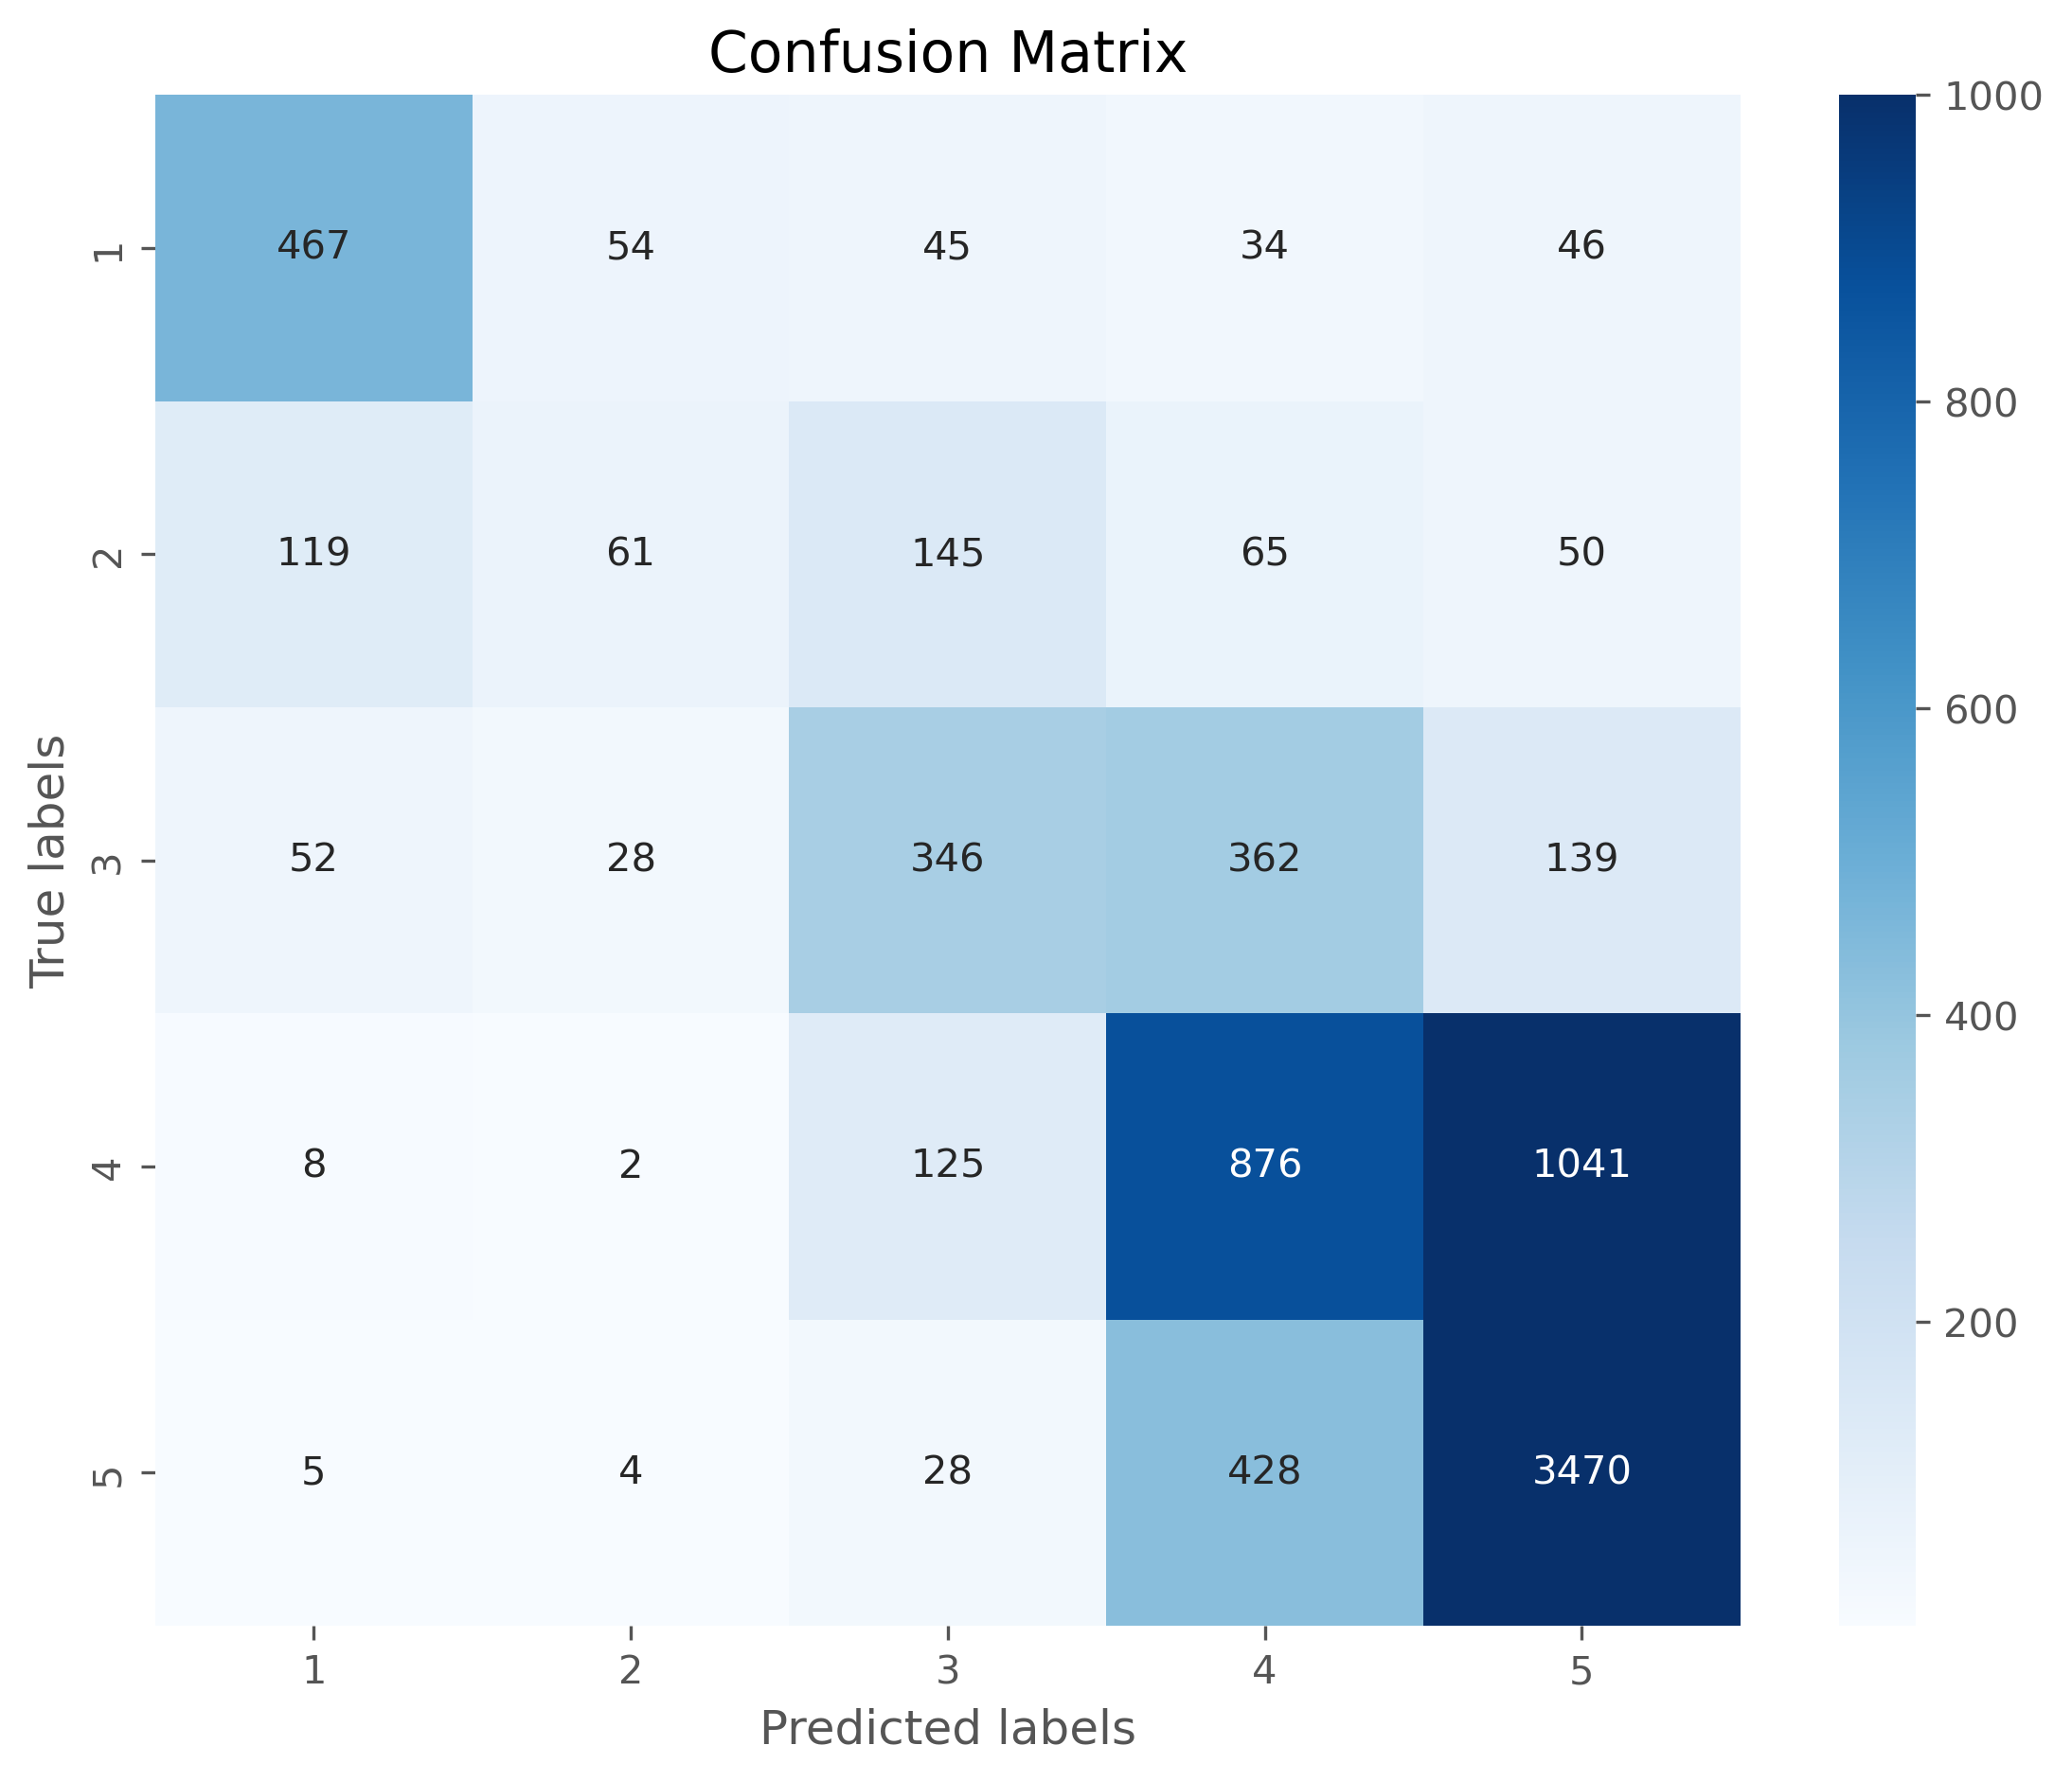

In [19]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, predictions, labels=model.classes_)

# Plotting the confusion matrix with a heatmap
plt.figure(figsize=(9,7), dpi=300)
sb.heatmap(cm, annot=True, fmt='d',
           cmap='Blues',
           xticklabels=model.classes_,
           yticklabels=model.classes_,
           vmax=1000,
          )
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

#### Look at the Vectors

How do our vectors look like?
Luckily, they are stored as sparse arrays so that only the (few) non-zero elements are actually being kept in memory. Often, our document tfidf-vectors will only contain a tiny fraction of all included n-grams:

In [20]:
tfidf_vectors[0, :].data

array([0.20140989, 0.37750596, 0.22927572, 0.32327298, 0.26211929,
       0.35615086, 0.19799178, 0.19654302, 0.21729833, 0.18328515,
       0.24375703, 0.22733288, 0.2354731 , 0.37297901])

In [21]:
tfidf_vectors[0, :].indices

array([5721, 1603, 2619, 3070, 2658,  203, 1161, 1948,  499, 4137, 1045,
        305, 3471, 2637], dtype=int32)

And? What has our model actually learned?

In [22]:
example_vector = pd.DataFrame({
    "word": vectorizer.get_feature_names_out()[tfidf_vectors[0, :].indices],
    "tfidf": tfidf_vectors[0, :].data
})
example_vector

,word,tfidf
0,want,0.201410
1,discover,0.377506
2,how,0.229276
3,lived,0.323273
4,ice,0.262119
5,ages,0.356151
6,come,0.197992
7,expensive,0.196543
8,bad,0.217298
9,quality,0.183285


### Logistic Regression model + n-grams

Let us now re-run the same thing, but use n-grams.

In [23]:
vectorizer = TfidfVectorizer(
    min_df=10, max_df=0.2,
    max_features=10000,
    ngram_range=(1, 3)
)  
tfidf_vectors = vectorizer.fit_transform(X_train)
tfidf_vectors.shape

(32000, 10000)

In [24]:
vectorizer.get_feature_names_out()[-100:]

array(['you can buy', 'you can choose', 'you can eat', 'you can enjoy',
       'you can find', 'you can get', 'you can go', 'you can have',
       'you can order', 'you can see', 'you can sit', 'you can try',
       'you cannot', 'you choose', 'you come', 'you could', 'you do',
       'you do not', 'you don', 'you don have', 'you don want', 'you eat',
       'you enjoy', 'you enter', 'you expect', 'you feel',
       'you feel like', 'you find', 'you for', 'you get', 'you get to',
       'you go', 'you go to', 'you had', 'you have', 'you have the',
       'you have to', 'you in', 'you just', 'you know', 'you like',
       'you ll', 'you ll be', 'you ll have', 'you love', 'you make',
       'you may', 'you might', 'you must', 'you must visit', 'you need',
       'you need to', 'you order', 'you pay', 'you pay for', 'you re',
       'you re in', 'you re looking', 'you re not', 'you really',
       'you see', 'you should', 'you sit', 'you that', 'you the',
       'you to', 'you try', 'you 

In [25]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=300)  # don't worry it also works without setting max_iter
model.fit(tfidf_vectors, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [26]:
tfidf_vectors_test = vectorizer.transform(X_test)
predictions = model.predict(tfidf_vectors_test)

In [27]:
np.round(predictions[:20], 1)

array([5, 4, 3, 1, 4, 5, 1, 4, 5, 5, 4, 5, 5, 4, 4, 4, 4, 1, 5, 5])

In [28]:
y_test[:20].values

array([4, 3, 3, 1, 4, 4, 1, 4, 4, 5, 5, 4, 5, 5, 5, 3, 1, 1, 4, 5])

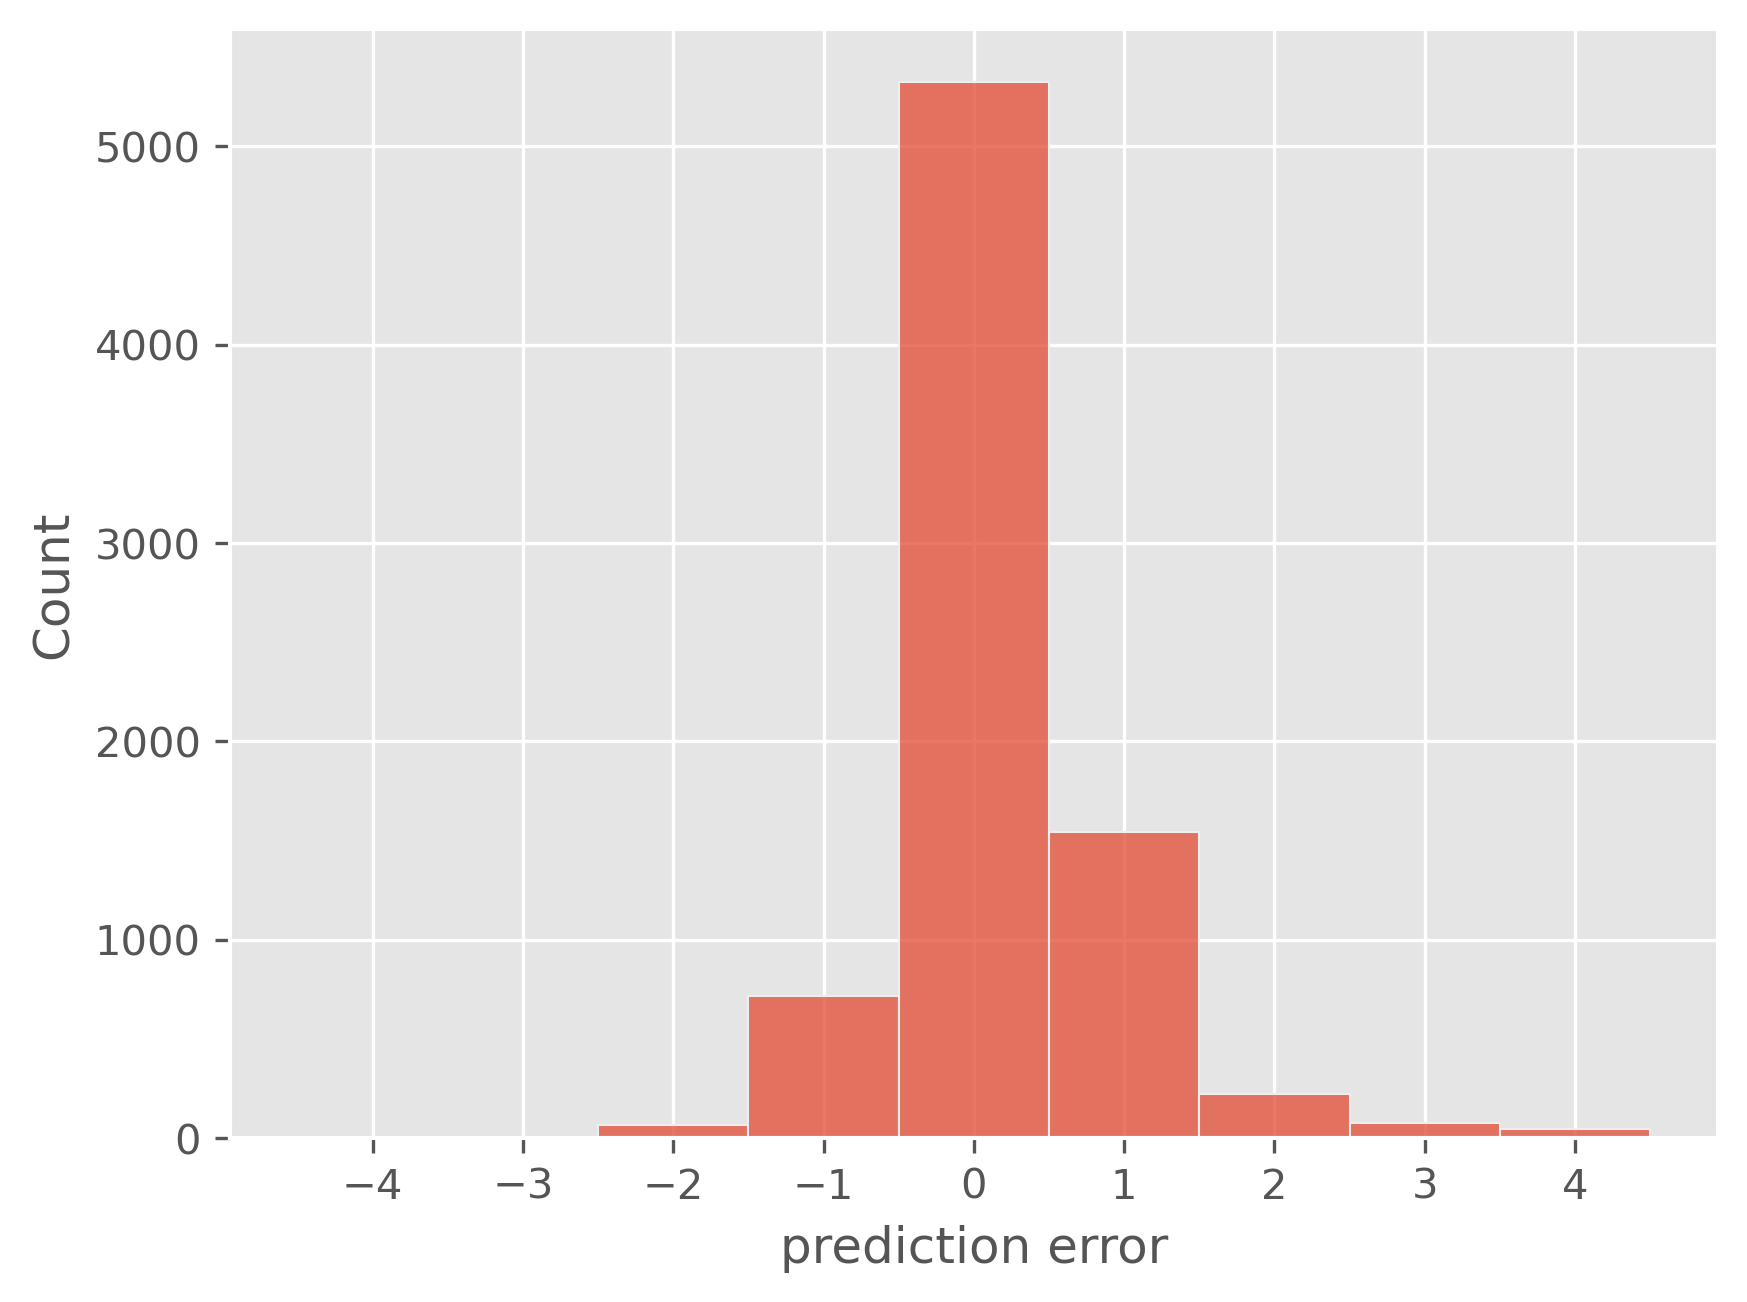

In [29]:
bins = np.arange(-4.5, 5.5, 1)

plt.figure(dpi=300)
sb.histplot(predictions - y_test, bins=bins)
plt.xlabel("prediction error")
plt.xticks(range(-4, 5))
plt.show()

In [30]:
print(f"Mean absolute error (MAE): {np.abs(predictions - y_test).mean():.4f}")

Mean absolute error (MAE): 0.4079


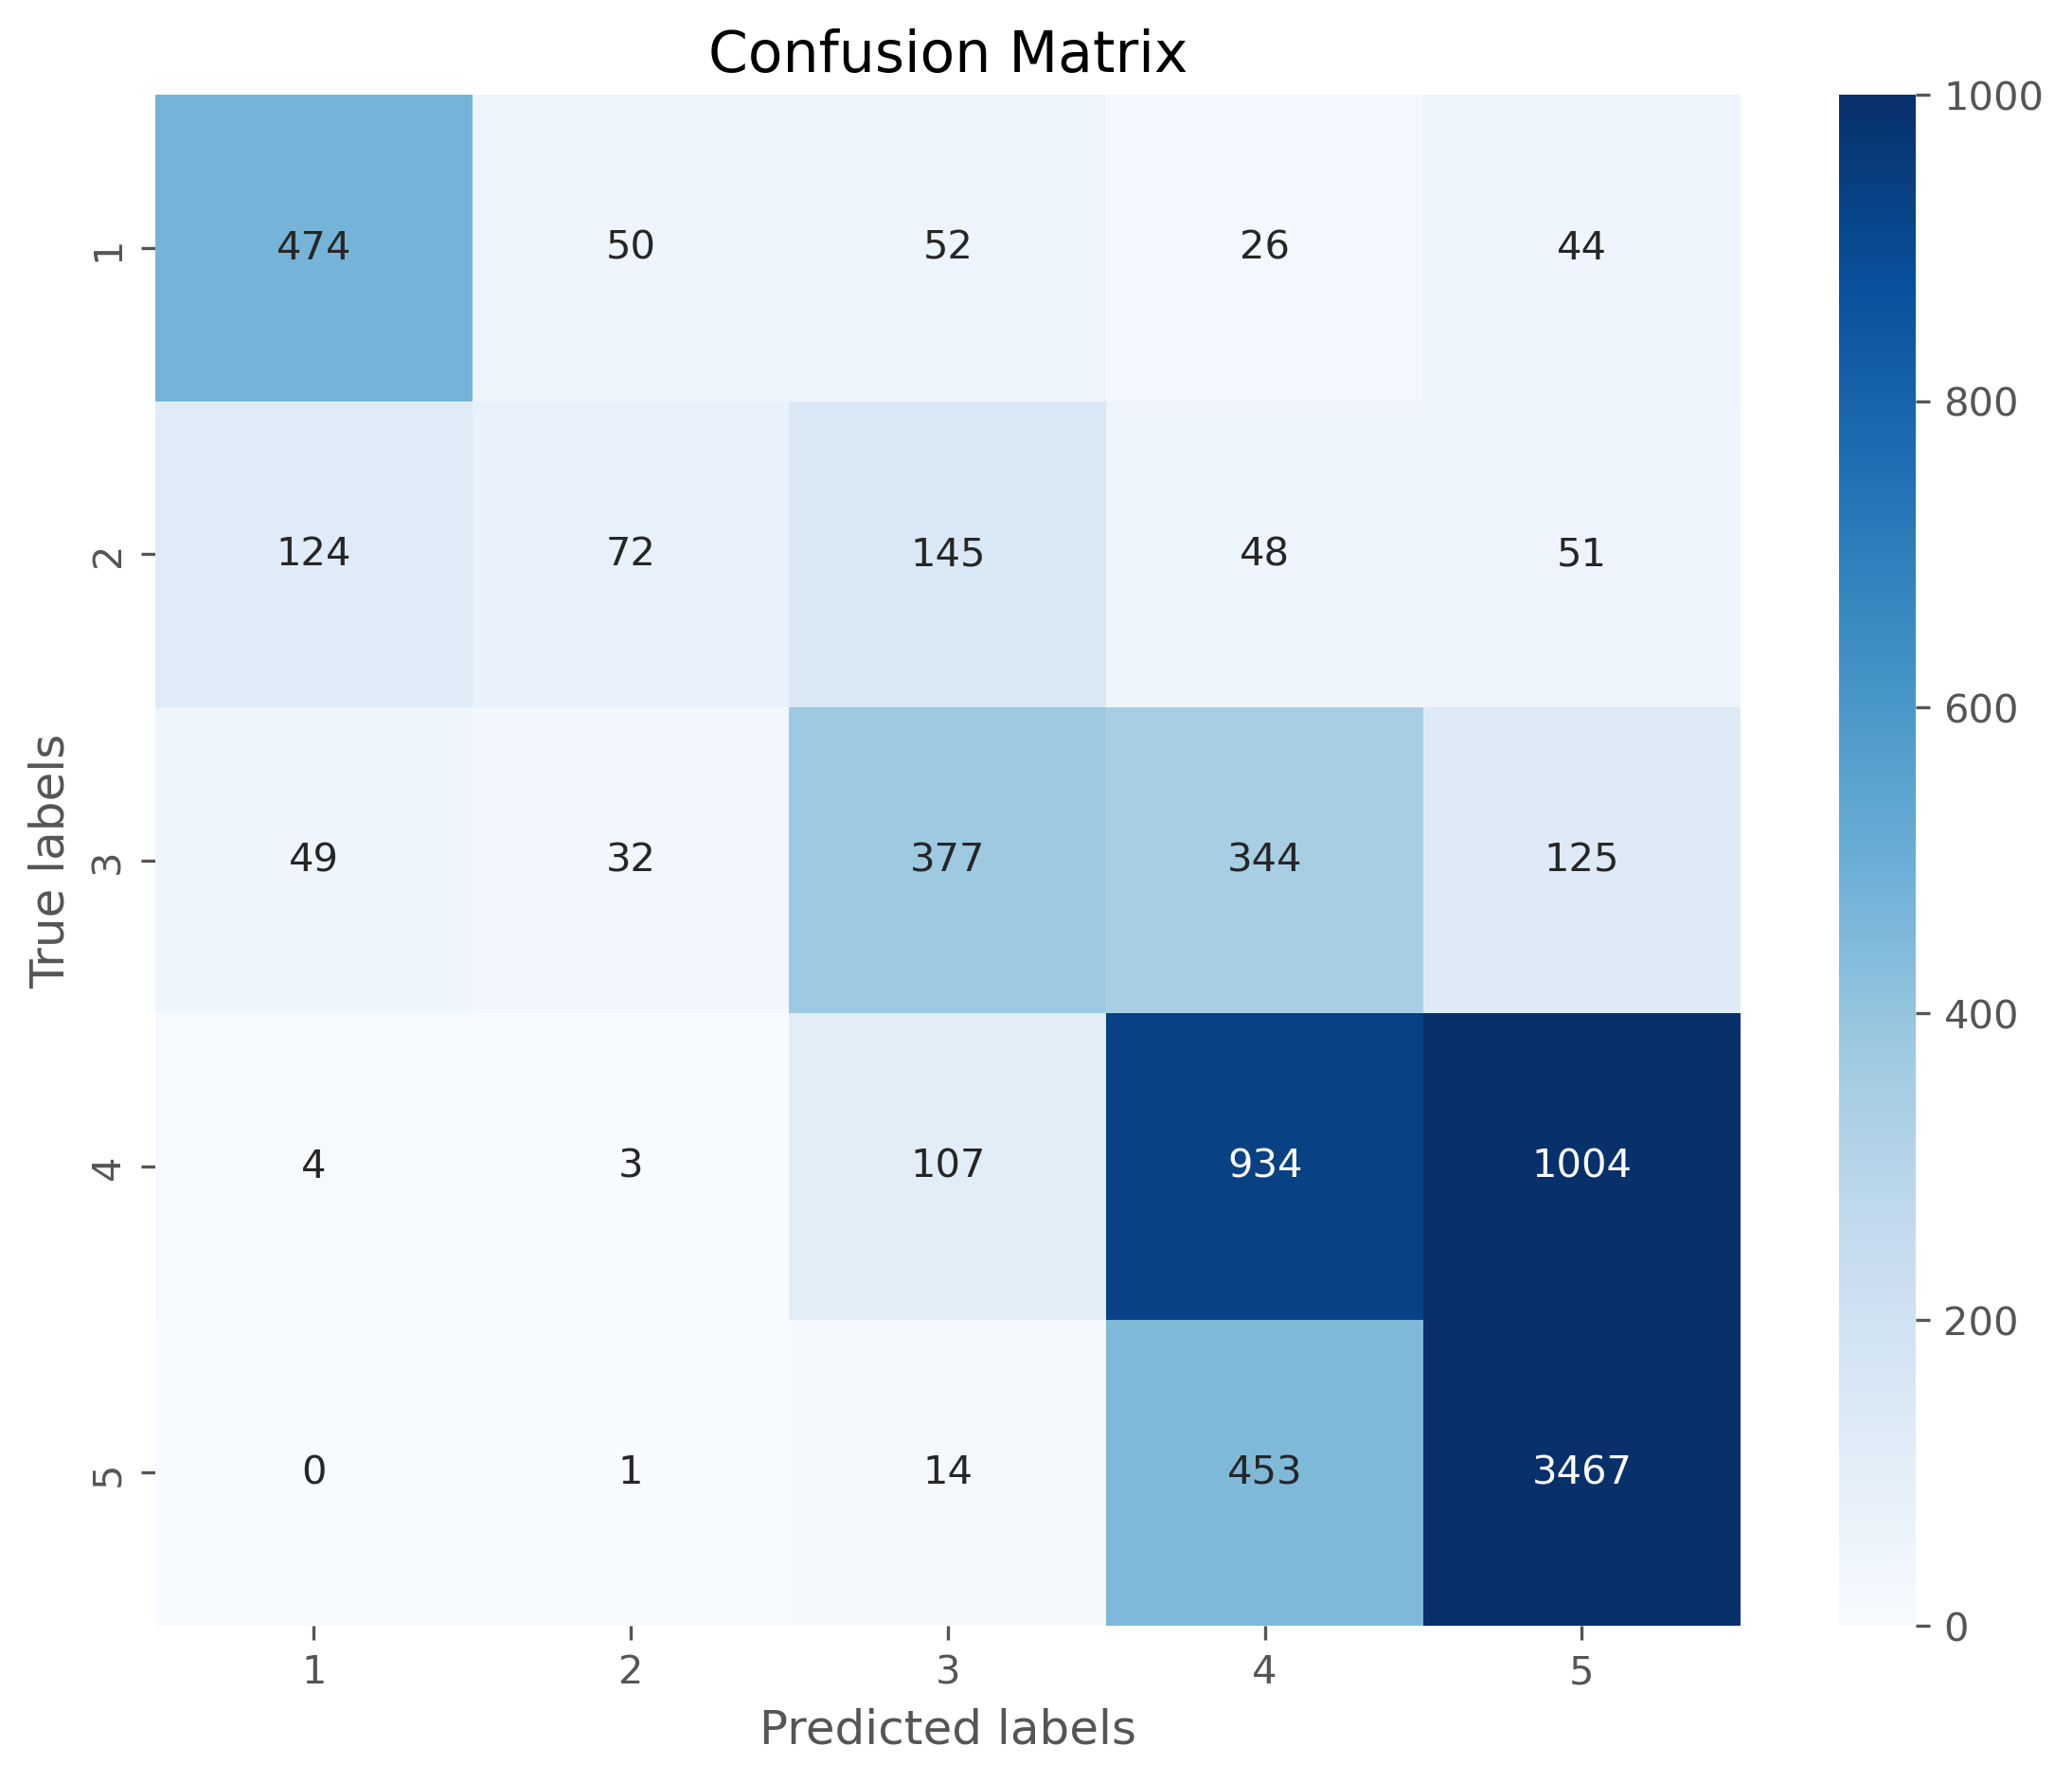

In [31]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, predictions, labels=model.classes_)

# Plotting the confusion matrix with a heatmap
plt.figure(figsize=(9,7), dpi=300)
sb.heatmap(
    cm, annot=True, fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_,
    vmax=1000
)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

### Did the 2-grams and 3-grams help?
Well, the prediction accuracy only got slightly better. So, it seems to have *some* effect, but nothing spectacular. However, this is not a general finding and might look very differently for other datasets or problems.

We can now also look at the ngrams that have the largest impact on the model predictions:

In [32]:
ngrams = pd.DataFrame({
    "ngram": vectorizer.get_feature_names_out(),
    "weight": model.coef_[0]
})
ngrams.sort_values("weight")

,ngram,weight
2032,delicious,-3.233019
8733,very good,-2.836569
2486,excellent,-2.826208
7223,tasty,-2.467226
1297,bit,-2.320507
...,...,...
1039,avoid,4.343721
6372,rude,4.346624
1083,bad,5.020163
9821,worst,5.038636


Here, too, we find only very few 2-grams in the top-20 and bottom-20 lists. Most of the times, the model still seems to judge the reviews based on individual words.

In [33]:
ngrams.sort_values("weight").head(20)

,ngram,weight
2032,delicious,-3.233019
8733,very good,-2.836569
2486,excellent,-2.826208
7223,tasty,-2.467226
1297,bit,-2.320507
2999,friendly,-2.292617
991,atmosphere,-2.214971
7362,the best,-1.963407
5031,nice,-1.957365
8991,was good,-1.952259


In [34]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

[[ 474   50   52   26   44]
 [ 124   72  145   48   51]
 [  49   32  377  344  125]
 [   4    3  107  934 1004]
 [   0    1   14  453 3467]]
              precision    recall  f1-score   support

           1       0.73      0.73      0.73       646
           2       0.46      0.16      0.24       440
           3       0.54      0.41      0.46       927
           4       0.52      0.46      0.48      2052
           5       0.74      0.88      0.80      3935

    accuracy                           0.67      8000
   macro avg       0.60      0.53      0.54      8000
weighted avg       0.64      0.67      0.65      8000



### Confusion matrix
The confusion matrix can tell us a lot about where the model works well and where it fails. Often is is more accessible if the matrix is plotted, for instance using seaborns `heatmap`.

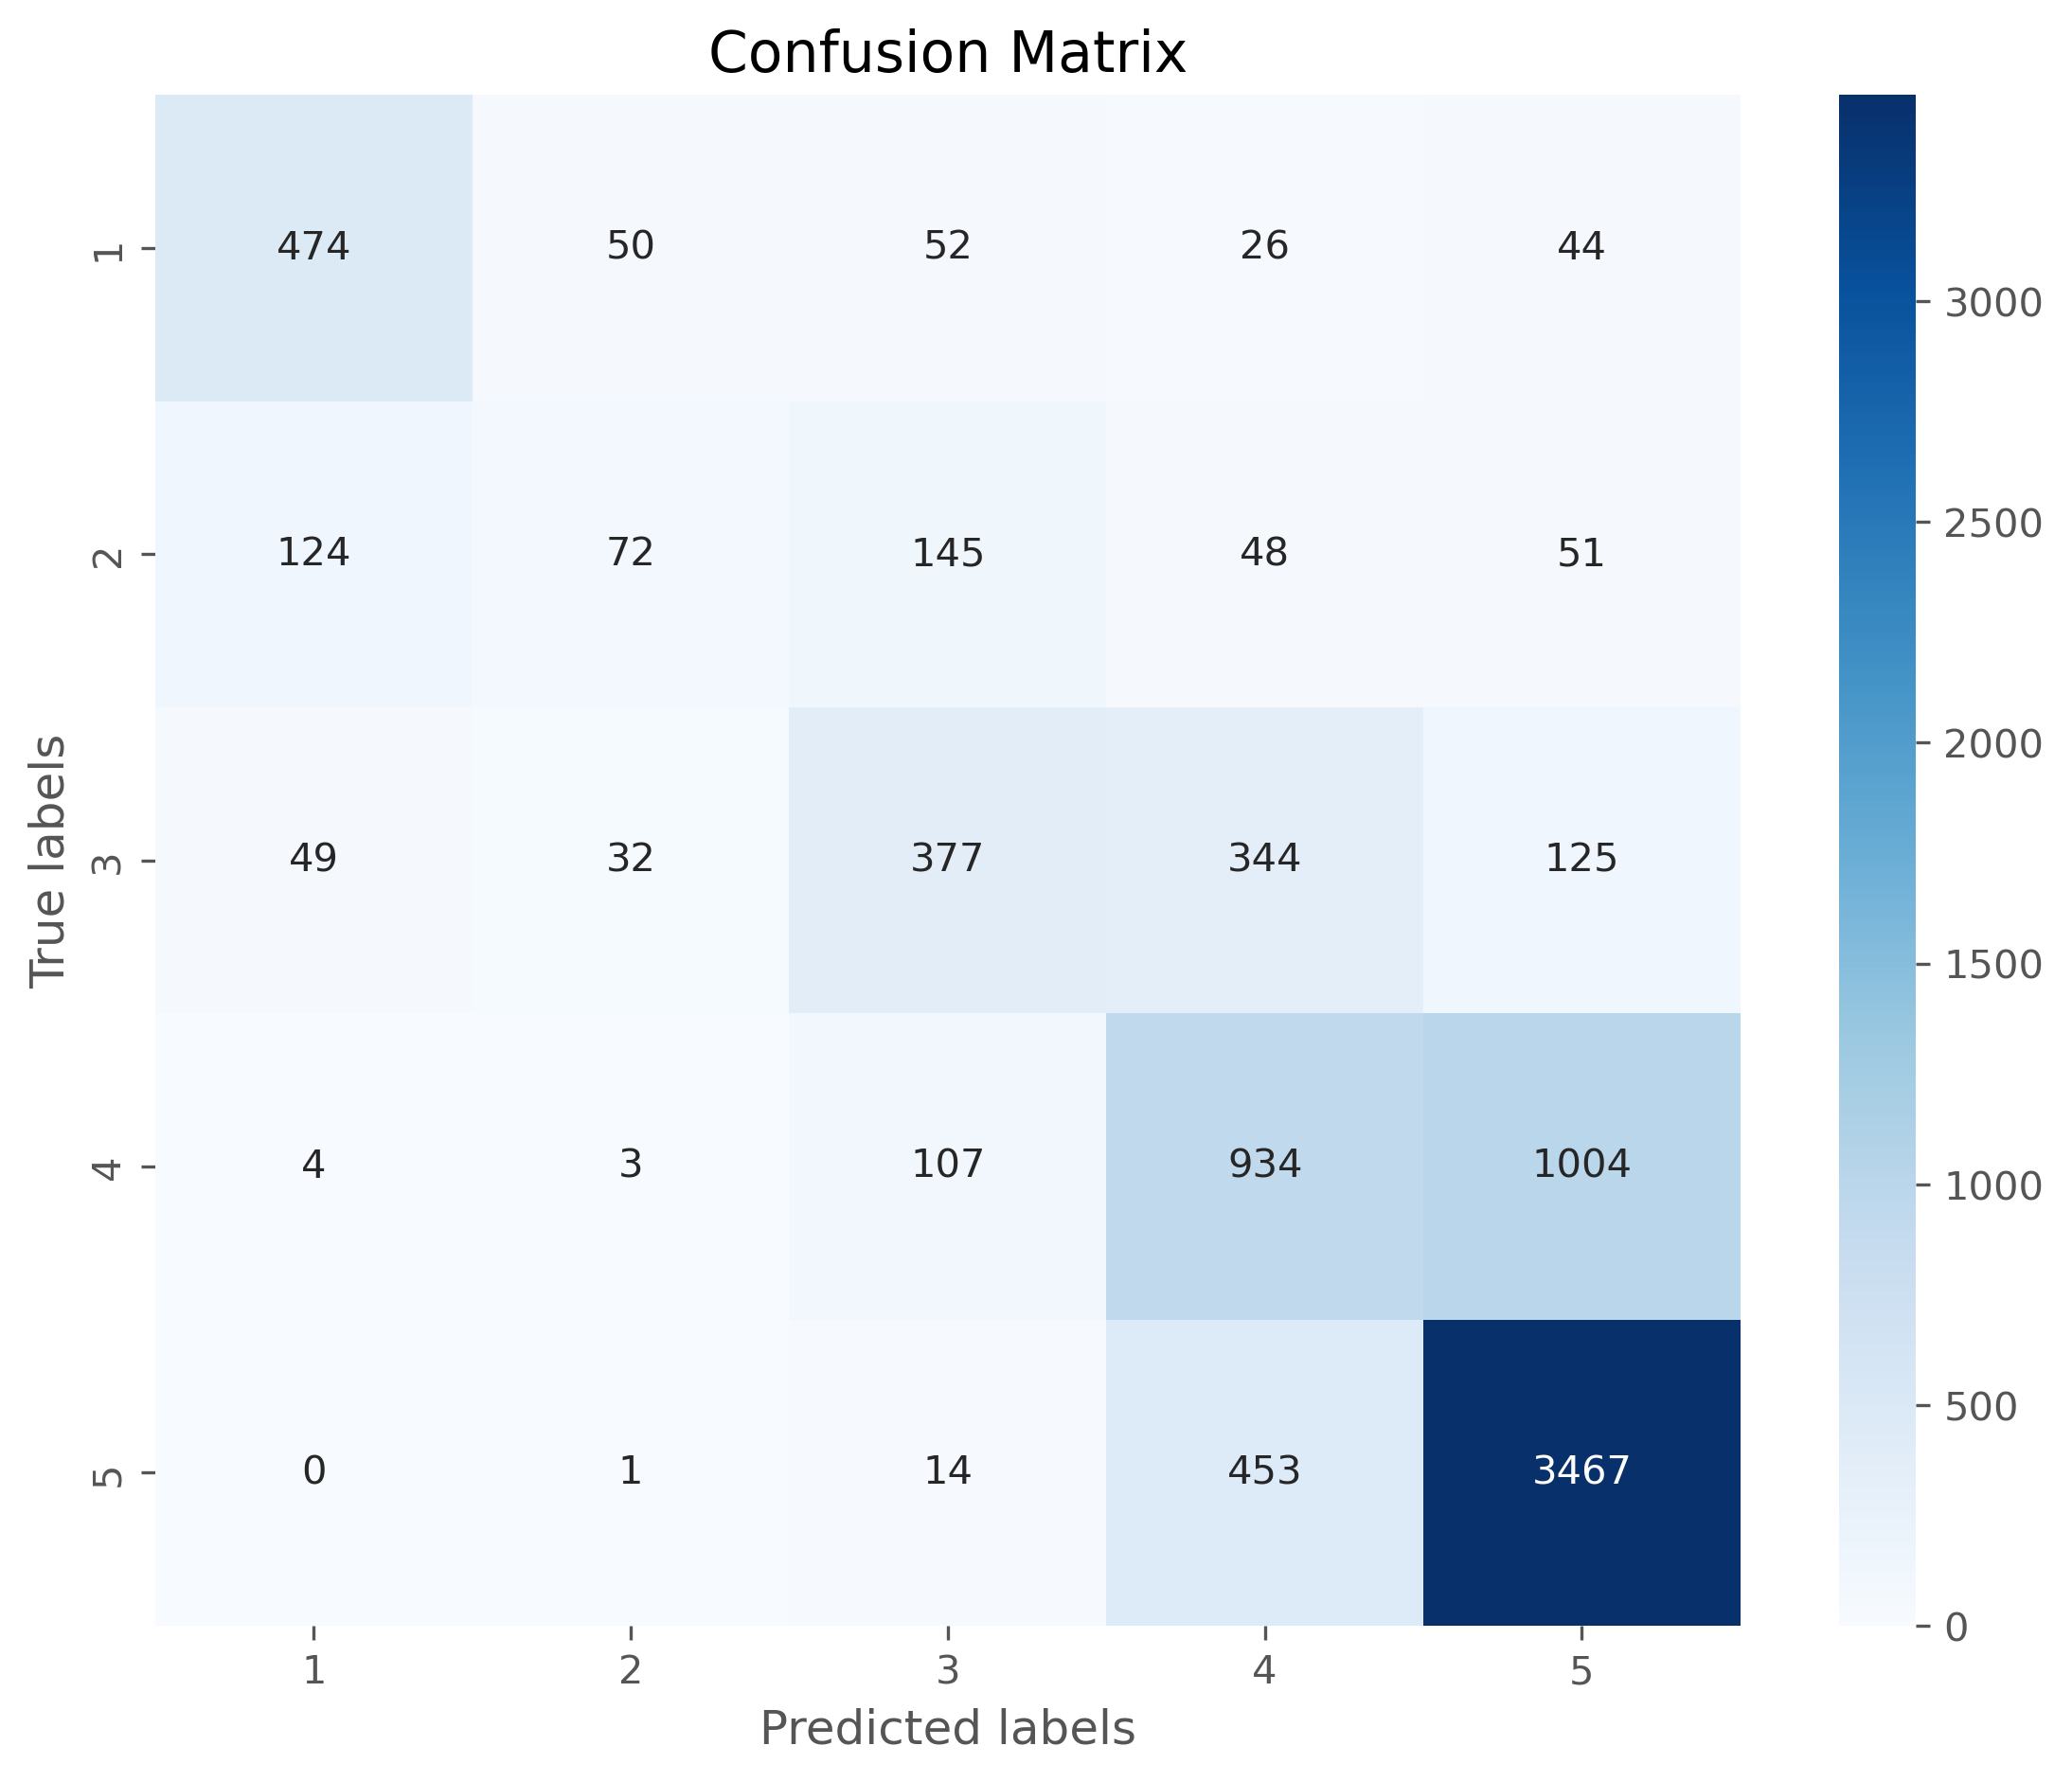

In [35]:
cm = confusion_matrix(y_test, predictions, labels=model.classes_)

# Plotting the confusion matrix with a heatmap
plt.figure(figsize=(9,7), dpi=300)
sb.heatmap(cm, annot=True, fmt='d',
           cmap='Blues',
           xticklabels=model.classes_,
           yticklabels=model.classes_)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

## Find similar documents with tfidf
So far, we used the tfidf-vectors as feature vectors to train machine learning models. As we just saw, this works very well to predict review rating or to classify documents as positive/negative (=sentiment analysis).

But there is more we can do with tfidf vectors.
Why not use the vectors to compute distances or similarities? This way, we can search for the most similar documents in a corpus!

In [36]:
vectorizer = TfidfVectorizer(
    min_df=10, max_df=0.2,
    max_features=25000,
    ngram_range=(1, 3)
)  
tfidf_vectors = vectorizer.fit_transform(X_train)
tfidf_vectors.shape

(32000, 25000)

In [37]:
tfidf_vectors.shape

(32000, 25000)

In [38]:
X_train.shape

(32000,)

#### Compare one vector to all other vectors
Even though we here deal with very large vectors, computing similarities or angles between these vectors is compuationally very efficient. This means, we can simply compare a the tfidf vector of a given text to all > 140,000 documents in virtually no time!

In order for this to work, however, we should not rely on for-loops. Those are inherently slow in Python. We rather use optimized functions for this such as from `sklear.metrics.pairwise`.

In [39]:
from sklearn.metrics.pairwise import cosine_similarity

review_id = -11#-9#-2
query_vector = tfidf_vectors[review_id, :]

cosine_similarities = cosine_similarity(query_vector, tfidf_vectors).flatten()
cosine_similarities.shape

(32000,)

In [40]:
np.sort(cosine_similarities)[::-1]

array([1.        , 0.17378527, 0.14885286, ..., 0.        , 0.        ,
       0.        ], shape=(32000,))

In [41]:
np.argsort(cosine_similarities)[::-1]

array([31989, 20283, 29369, ..., 31996, 31964, 22342], shape=(32000,))

In [42]:
top5_idx = np.argsort(cosine_similarities)[::-1][1:6]
top5_idx

array([20283, 29369, 29235, 11133,  4271])

Let us now look at the results of our search by displaying the top-5 most similar documents (according to the cosine score on the tfidf-vectors). This usually doesn't work perfectly, but it does work to quite some extent. Try it out yourself and have a look at what documents this finds for you!

In [43]:
print("\n****Original document:****")
print(X_train.iloc[review_id])

for i in top5_idx:
    print(f"\n----Document with similarity {cosine_similarities[i]:.3f}:----")
    print(X_train.iloc[i])


****Original document:****
Can get buckets of beers for between 4 -5 Euros (5 beers in a bucket). Offer cheap sandwitches, rations of things such as calamari (which I had and was great). They have a terrace and a large screen TV for the football if that floats your boat.

----Document with similarity 0.174:----
Great place to call in before or after the football at Rel Madrid.Good selection of beers and reasonable prices.

----Document with similarity 0.149:----
This place located next to Moncloa station is a cheap option to get beers for a cheap price and tapas. They have tvs broadcasting football games as well.

----Document with similarity 0.142:----
excellent "ensaladilla rusa" and the "ventresca salad" was delicious too. Big cold Heineken pints and a large selection of beers. Will be back when I come back to Madrid

----Document with similarity 0.139:----
Great local bar for breakfast and delicious snacks. Good variety of beers with friendly attentive staff. It’s always busy with